# Results Tables & Charts
Reads `res/results.csv` and produces LaTeX tables (mean ± std across folds) and timing bar charts.

In [1]:
# results_tables_extended_v1
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load every available results CSV and concatenate. The Q1/Q2 scripts write
# per-task files; Q3 writes the legacy results.csv. Newer error metrics live
# in dedicated *_error_*.csv files. All share the same schema, including
# the ``tabpfn_version`` column added when both v2.6 and v3 were enabled.
RES_DIR = Path("../res")
_CSV_NAMES = [
    "results.csv",
    "results_severity.csv",
    "results_frequency.csv",
    "results_error_severity.csv",
    "results_error_frequency.csv",
    "results_fretelematic.csv",
]
_frames = []
for name in _CSV_NAMES:
    p = RES_DIR / name
    if p.exists():
        _frames.append(pd.read_csv(p))
if not _frames:
    raise FileNotFoundError(
        f"No results CSVs found in {RES_DIR.resolve()}. "
        "Run the experiment scripts first."
    )
df = pd.concat(_frames, ignore_index=True)

# Older CSV writes (before the tabpfn_version column existed) lack the
# column entirely; coerce missing / NaN values to "" so non-TabPFN rows do
# not introduce NaN-keyed groups in any aggregation downstream.
if "tabpfn_version" not in df.columns:
    df["tabpfn_version"] = ""
df["tabpfn_version"] = df["tabpfn_version"].fillna("").astype(str)

# Deduplicate including tabpfn_version so v2.6 and v3 rows for the same
# (experiment, dataset, model, task, fold, metric) are kept as separate rows.
df = df.drop_duplicates(
    subset=["experiment_id", "dataset", "model", "task", "fold", "metric",
            "tabpfn_version"],
    keep="last",
)

# Synthesize a display label that fuses ``model`` + ``tabpfn_version`` so
# every downstream groupby / filter / plot can key on a single string.
# Non-TabPFN rows (empty tabpfn_version) keep their original model name.
df["model_display"] = df.apply(
    lambda r: f"{r['model']}_{r['tabpfn_version']}" if r["tabpfn_version"] else r["model"],
    axis=1,
)

# Per-fold rows only (exclude pooled aggregate)
folds = df[df["fold"] != "pooled"].copy()
folds["fold"] = folds["fold"].astype(int)

# Consistent display-model order. Each TabPFN size appears once per
# version so v2.6 and v3 are listed side-by-side.
_TABPFN_SIZES = ["", "2000", "5000", "10000", "50000", "100000", "full"]
_TABPFN_VERSIONS = ["v2_6", "v3"]

def _tabpfn_label(size: str, version: str) -> str:
    base = "tabpfn" if size == "" else f"tabpfn_{size}"
    return f"{base}_{version}"

MODEL_ORDER = ["glm", "xgboost"] + [
    _tabpfn_label(s, v) for s in _TABPFN_SIZES for v in _TABPFN_VERSIONS
]

def mean_std_table(data, metric, index_col="model_display"):
    """Pivot mean±std LaTeX strings, rows ordered by MODEL_ORDER."""
    sub = data[data["metric"] == metric]
    stats = (
        sub.groupby(["dataset", index_col])["value"]
        .agg(["mean", "std"])
        .reset_index()
    )
    stats["mean_std"] = stats.apply(
        lambda r: f"{r['mean']:.4f} $\\pm$ {r['std']:.4f}", axis=1
    )
    table = stats.pivot(index=index_col, columns="dataset", values="mean_std")
    order = [m for m in MODEL_ORDER if m in table.index]
    return table.loc[order]

## 1. Deviance table — Q1 Severity (Gamma deviance, lower is better)

In [2]:
sev = folds[folds["task"] == "sev"]
table_sev = mean_std_table(sev, "gamma_deviance")
print(table_sev.to_latex(
    escape=False,
    caption="Gamma deviance (mean $\\pm$ std over 5 folds) for severity models.",
    label="tab:severity"
))

\begin{table}
\caption{Gamma deviance (mean $\pm$ std over 5 folds) for severity models.}
\label{tab:severity}
\begin{tabular}{lll}
\toprule
dataset & beMTPL97 & freMTPL2 \\
model_display &  &  \\
\midrule
glm & 2.0463 $\pm$ 0.0668 & 1.7553 $\pm$ 0.2632 \\
xgboost & 2.0553 $\pm$ 0.0791 & 1.5976 $\pm$ 0.1408 \\
tabpfn_v2_6 & 3.7216 $\pm$ 0.2294 & 2.6565 $\pm$ 0.6466 \\
tabpfn_v3 & 3.7329 $\pm$ 0.2289 & 2.6407 $\pm$ 0.6551 \\
\bottomrule
\end{tabular}
\end{table}



## 2. Deviance table — Q2 Frequency (Poisson deviance, lower is better)

In [3]:
freq = folds[folds["task"] == "freq"]
table_freq = mean_std_table(freq, "poisson_deviance")
print(table_freq.to_latex(
    escape=False,
    caption="Poisson deviance (mean $\\pm$ std over 5 folds) for frequency models.",
    label="tab:frequency"
))

\begin{table}
\caption{Poisson deviance (mean $\pm$ std over 5 folds) for frequency models.}
\label{tab:frequency}
\begin{tabular}{lll}
\toprule
dataset & beMTPL97 & freMTPL2 \\
model_display &  &  \\
\midrule
glm & 0.5508 $\pm$ 0.0041 & 0.2961 $\pm$ 0.0011 \\
xgboost & 0.5829 $\pm$ 0.0041 & 0.3441 $\pm$ 0.0007 \\
tabpfn_2000_v2_6 & 0.5920 $\pm$ 0.0091 & 0.5005 $\pm$ 0.2271 \\
tabpfn_2000_v3 & 0.6154 $\pm$ 0.0082 & 0.3471 $\pm$ 0.0189 \\
tabpfn_5000_v2_6 & 0.5853 $\pm$ 0.0224 & 0.5533 $\pm$ 0.0998 \\
tabpfn_5000_v3 & 0.6262 $\pm$ 0.0148 & 0.3647 $\pm$ 0.0164 \\
tabpfn_10000_v2_6 & 0.5740 $\pm$ 0.0093 & 0.5567 $\pm$ 0.1131 \\
tabpfn_10000_v3 & 0.6362 $\pm$ 0.0189 & 0.3795 $\pm$ 0.0152 \\
tabpfn_50000_v2_6 & 0.5607 $\pm$ 0.0023 & 0.3636 $\pm$ 0.0192 \\
tabpfn_50000_v3 & 0.6264 $\pm$ 0.0023 & 0.3644 $\pm$ 0.0160 \\
tabpfn_100000_v2_6 & 0.5573 $\pm$ 0.0043 & 0.3466 $\pm$ 0.0105 \\
tabpfn_100000_v3 & 0.6248 $\pm$ 0.0200 & 0.3524 $\pm$ 0.0113 \\
tabpfn_full_v3 & 0.6278 $\pm$ 0.0188 & 0.3385 

## 3. Combined frequency + severity table

In [4]:
def mean_std_series(data, metric):
    """Return a Series indexed by model_display with mean±std strings."""
    sub = data[data["metric"] == metric]
    stats = sub.groupby("model_display")["value"].agg(["mean", "std"])
    return stats.apply(lambda r: f"{r['mean']:.3f} $\\pm$ {r['std']:.3f}", axis=1)

datasets = ["freMTPL2", "beMTPL97"]
task_metric = [("freq", "poisson_deviance"), ("sev", "gamma_deviance")]

cols = {}
for dataset in datasets:
    sub_ds = folds[folds["dataset"] == dataset]
    for task, metric in task_metric:
        sub_task = sub_ds[sub_ds["task"] == task]
        cols[(dataset, task)] = mean_std_series(sub_task, metric)

combined = pd.DataFrame(cols)
combined.columns = pd.MultiIndex.from_tuples(combined.columns, names=["Dataset", "Task"])

# Consistent row order (display labels)
order = [m for m in MODEL_ORDER if m in combined.index]
combined = combined.loc[order]

print(combined.to_latex(
    escape=False,
    caption="Poisson deviance (frequency) and Gamma deviance (severity), mean $\\pm$ std over 5 folds.",
    label="tab:combined"
))

\begin{table}
\caption{Poisson deviance (frequency) and Gamma deviance (severity), mean $\pm$ std over 5 folds.}
\label{tab:combined}
\begin{tabular}{lllll}
\toprule
Dataset & \multicolumn{2}{r}{freMTPL2} & \multicolumn{2}{r}{beMTPL97} \\
Task & freq & sev & freq & sev \\
model_display &  &  &  &  \\
\midrule
glm & 0.296 $\pm$ 0.001 & 1.755 $\pm$ 0.263 & 0.551 $\pm$ 0.004 & 2.046 $\pm$ 0.067 \\
xgboost & 0.344 $\pm$ 0.001 & 1.598 $\pm$ 0.141 & 0.583 $\pm$ 0.004 & 2.055 $\pm$ 0.079 \\
tabpfn_v2_6 & NaN & 2.656 $\pm$ 0.647 & NaN & 3.722 $\pm$ 0.229 \\
tabpfn_v3 & NaN & 2.641 $\pm$ 0.655 & NaN & 3.733 $\pm$ 0.229 \\
tabpfn_2000_v2_6 & 0.501 $\pm$ 0.227 & NaN & 0.592 $\pm$ 0.009 & NaN \\
tabpfn_2000_v3 & 0.347 $\pm$ 0.019 & NaN & 0.615 $\pm$ 0.008 & NaN \\
tabpfn_5000_v2_6 & 0.553 $\pm$ 0.100 & NaN & 0.585 $\pm$ 0.022 & NaN \\
tabpfn_5000_v3 & 0.365 $\pm$ 0.016 & NaN & 0.626 $\pm$ 0.015 & NaN \\
tabpfn_10000_v2_6 & 0.557 $\pm$ 0.113 & NaN & 0.574 $\pm$ 0.009 & NaN \\
tabpfn_10000_v3 & 0.37

## 4. Timing bar charts — fit+predict time per dataset (scalability)

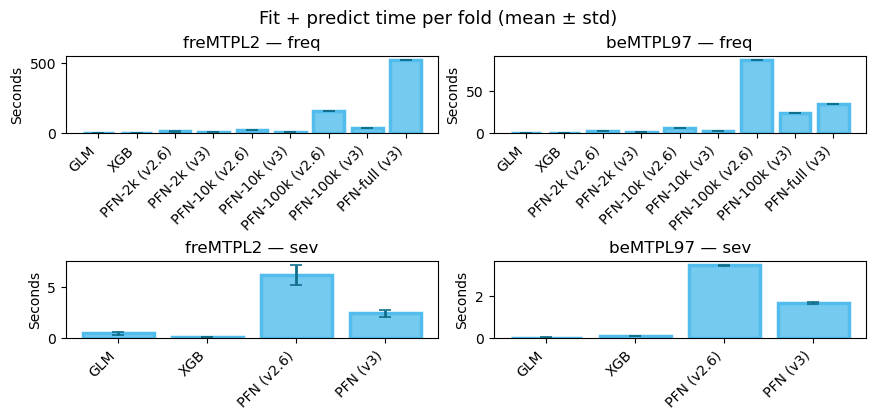

Saved to res/timing_barchart.pdf


In [5]:
timing = folds[folds["metric"] == "fit_predict_seconds"]

timing_stats = (
    timing.groupby(["dataset", "task", "model_display"])["value"]
    .agg(["mean", "std"])
    .reset_index()
)

tasks = ["freq", "sev"]

# Sizes dropped from the timing x-axis to keep labels legible.
_TIMING_DROP_SIZES = {"5000", "50000"}

def _abbrev_model(name: str) -> str:
    """Compact x-tick label for the timing chart.

    Examples:
        glm                  -> GLM
        xgboost              -> XGB
        tabpfn_v2_6          -> PFN (v2.6)
        tabpfn_2000_v3       -> PFN-2k (v3)
        tabpfn_100000_v2_6   -> PFN-100k (v2.6)
        tabpfn_full_v3       -> PFN-full (v3)
    """
    if name == "glm":
        return "GLM"
    if name == "xgboost":
        return "XGB"
    if not name.startswith("tabpfn"):
        return name
    rest = name[len("tabpfn"):].lstrip("_")
    if rest.startswith("v"):
        size_token, version_token = "", rest
    else:
        size_token, _, version_token = rest.partition("_")
    size_map = {"2000": "2k", "5000": "5k", "10000": "10k",
                "50000": "50k", "100000": "100k", "full": "full"}
    version_label = "v2.6" if version_token == "v2_6" else "v3"
    if size_token == "":
        return f"PFN ({version_label})"
    return f"PFN-{size_map.get(size_token, size_token)} ({version_label})"


def _keep_for_timing(model_display: str, task: str) -> bool:
    """Drop 5k / 50k subsample rows from the freq timing panel."""
    if task != "freq" or not model_display.startswith("tabpfn_"):
        return True
    rest = model_display[len("tabpfn_"):]
    size_token = rest.split("_", 1)[0]
    return size_token not in _TIMING_DROP_SIZES


bar_outline = "#52BDEC"
bar_fill = (82 / 255, 189 / 255, 236 / 255, 0.8)
whisker_color = "#116E8A"
fig_width_in = 7.2*1.2
fig_height_in = 3.4*1.2

fig, axes = plt.subplots(
    len(tasks),
    len(datasets),
    figsize=(fig_width_in, fig_height_in),
    squeeze=False,
    constrained_layout=True,
)

for row, task in enumerate(tasks):
    for col, dataset in enumerate(datasets):
        ax = axes[row][col]
        sub = timing_stats[(timing_stats["task"] == task) & (timing_stats["dataset"] == dataset)].copy()
        if sub.empty:
            ax.set_visible(False)
            continue
        # Drop sizes that crowd the x-axis on the frequency panel.
        sub = sub[sub["model_display"].apply(lambda m: _keep_for_timing(m, task))]
        if sub.empty:
            ax.set_visible(False)
            continue
        # Apply consistent model order (display labels)
        sub["model_display"] = pd.Categorical(
            sub["model_display"],
            categories=[m for m in MODEL_ORDER if m in sub["model_display"].values],
            ordered=True,
        )
        sub = sub.sort_values("model_display")
        labels = [_abbrev_model(m) for m in sub["model_display"].astype(str)]
        ax.bar(
            labels,
            sub["mean"],
            yerr=sub["std"],
            capsize=4,
            color=bar_fill,
            edgecolor=bar_outline,
            linewidth=2.5,
            error_kw={"ecolor": whisker_color, "elinewidth": 2, "capthick": 1.2},
        )
        ax.set_title(f"{dataset} — {task}")
        ax.set_ylabel("Seconds")
        ax.tick_params(axis="x", rotation=45)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")

fig.suptitle("Fit + predict time per fold (mean ± std)", fontsize=13)
fig.savefig("../res/timing_barchart.pdf", bbox_inches="tight")
plt.show()
print("Saved to res/timing_barchart.pdf")

## 5. Pooled deviance table (single aggregate score)

In [6]:
pooled = df[df["fold"] == "pooled"].copy()
pooled_dev = pooled[pooled["metric"].isin(["gamma_deviance", "poisson_deviance"])]

table_pooled = pooled_dev.pivot_table(index="model_display", columns=["dataset", "task"], values="value")
order = [m for m in MODEL_ORDER if m in table_pooled.index]
table_pooled = table_pooled.loc[order]

print(table_pooled.round(4).to_latex(
    caption="Pooled out-of-fold deviance.",
    label="tab:pooled"
))

\begin{table}
\caption{Pooled out-of-fold deviance.}
\label{tab:pooled}
\begin{tabular}{lrrrr}
\toprule
dataset & \multicolumn{2}{r}{beMTPL97} & \multicolumn{2}{r}{freMTPL2} \\
task & freq & sev & freq & sev \\
model_display &  &  &  &  \\
\midrule
glm & 0.550800 & 2.046400 & 0.296100 & 1.755300 \\
xgboost & 0.582900 & 2.055500 & 0.344100 & 1.597500 \\
tabpfn_v2_6 & NaN & 3.722100 & NaN & 2.656400 \\
tabpfn_v3 & NaN & 3.733300 & NaN & 2.640600 \\
\bottomrule
\end{tabular}
\end{table}



## 6. Per-fold metrics — Frequency task
Poisson deviance and exposure-weighted RMSE (on the rate scale), shown per fold for each dataset that contains frequency data.

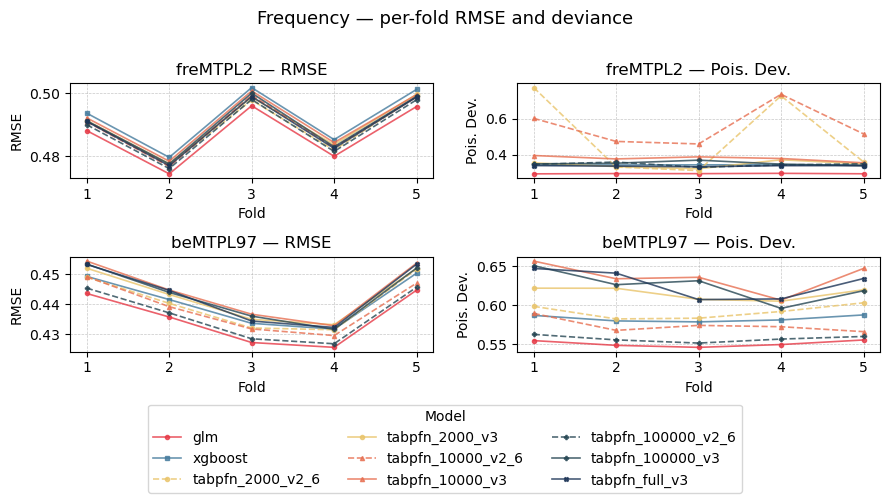

Saved to res/per_fold_freq.pdf


In [14]:
# Per-fold metrics for the frequency task — RMSE + Poisson deviance.
# Same colour + marker per size axis; v2.6 dashed, v3 solid.
_SIZE_STYLES = {
    "":        {"color": "#2A9D8F", "marker": "^"},
    "2000":    {"color": "#E9C46A", "marker": "o"},
    "5000":    {"color": "#F4A261", "marker": "s"},
    "10000":   {"color": "#E76F51", "marker": "^"},
    "50000":   {"color": "#9B5DE5", "marker": "D"},
    "100000":  {"color": "#264653", "marker": "P"},
    "full":    {"color": "#1D3557", "marker": "X"},
}
MODEL_STYLES = {
    "glm":     {"color": "#E63946", "marker": "o", "ls": "-"},
    "xgboost": {"color": "#457B9D", "marker": "s", "ls": "-"},
}
for _size, _base in _SIZE_STYLES.items():
    _base_label = "tabpfn" if _size == "" else f"tabpfn_{_size}"
    for _version, _ls in (("v2_6", "--"), ("v3", "-")):
        MODEL_STYLES[f"{_base_label}_{_version}"] = {**_base, "ls": _ls}

# RMSE first (left), deviance second (right) — mirrors the paper's discussion order.
FREQ_METRICS = [
    ("exposure_weighted_rmse_rate", "RMSE"),
    ("poisson_deviance",            "Pois. Dev."),
]
datasets = ["freMTPL2", "beMTPL97"]

# Subsample sizes to drop from the per-fold plots.
_PLOT_DROP_SIZES = {"5000", "50000"}

def _keep_for_plot(model_display: str) -> bool:
    if not model_display.startswith("tabpfn_"):
        return True
    rest = model_display[len("tabpfn_"):]
    size_token = rest.split("_", 1)[0]
    return size_token not in _PLOT_DROP_SIZES


# Shared dimensions across the freq and sev per-fold figures so they occupy
# the same footprint in the paper. The freq panel carries the larger legend,
# so the bottom strip is sized for it; the sev panel reuses the same numbers.
FIG_WIDTH_IN = 9
FIG_HEIGHT_IN = 5
LEGEND_BOTTOM = 0.18
LEGEND_NCOL = 3

# Only keep datasets that actually contain frequency rows.
freq_datasets = [
    d for d in datasets
    if not folds[(folds["dataset"] == d) & (folds["task"] == "freq")].empty
]

fig, axes = plt.subplots(
    len(freq_datasets), len(FREQ_METRICS),
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
    squeeze=False,
)

handles_labels = {}
for row, dataset in enumerate(freq_datasets):
    for col, (metric, label) in enumerate(FREQ_METRICS):
        ax = axes[row][col]
        sub = folds[
            (folds["dataset"] == dataset)
            & (folds["task"] == "freq")
            & (folds["metric"] == metric)
        ]
        models_present = [
            m for m in MODEL_ORDER
            if m in sub["model_display"].values and _keep_for_plot(m)
        ]
        for model in models_present:
            md = sub[sub["model_display"] == model].sort_values("fold")
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "o", "ls": "-"})
            line, = ax.plot(
                md["fold"] + 1, md["value"],
                color=style["color"], marker=style["marker"], ls=style["ls"],
                linewidth=1.2, markersize=3, label=model, alpha=0.8,
            )
            handles_labels[model] = line
        ax.set_title(f"{dataset} — {label}")
        ax.set_xlabel("Fold")
        ax.set_ylabel(label)
        if not sub.empty:
            ax.set_xticks(range(1, sub["fold"].nunique() + 1))
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

fig.suptitle("Frequency — per-fold RMSE and deviance", fontsize=13)
fig.tight_layout(rect=[0, LEGEND_BOTTOM, 1, 0.97])

ordered_handles = [handles_labels[m] for m in MODEL_ORDER if m in handles_labels]
ordered_labels  = [m for m in MODEL_ORDER if m in handles_labels]
fig.legend(
    ordered_handles, ordered_labels,
    loc="lower center", ncol=LEGEND_NCOL, bbox_to_anchor=(0.5, 0.0),
    title="Model", frameon=True,
)
fig.savefig("../res/per_fold_freq.pdf", bbox_inches="tight")
plt.show()
print("Saved to res/per_fold_freq.pdf")

## 7. Per-fold metrics — Severity task
Gamma deviance and unweighted RMSE, shown per fold for each dataset that contains severity data.

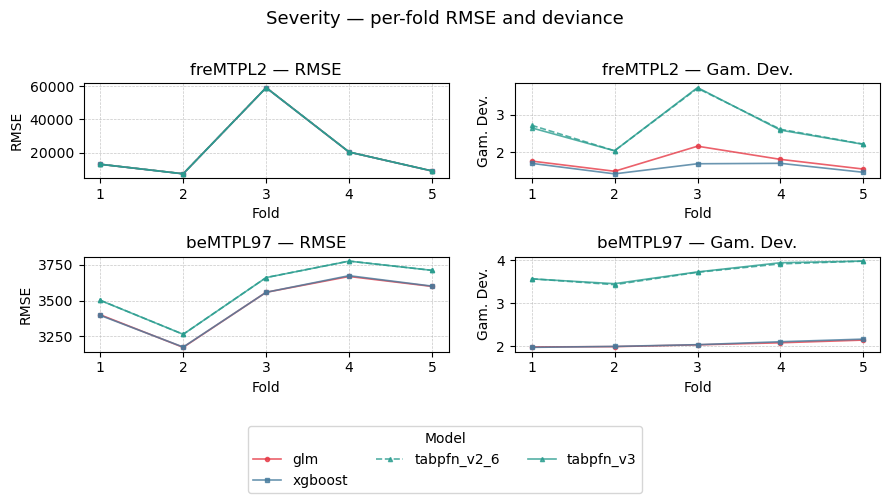

Saved to res/per_fold_sev.pdf


In [15]:
# Per-fold metrics for the severity task — unweighted RMSE + Gamma deviance.
# Reuses MODEL_STYLES and FIG_WIDTH_IN/FIG_HEIGHT_IN/LEGEND_* from the
# frequency cell so the two figures occupy identical footprints in the paper.

# RMSE first (left), deviance second (right) — mirrors the paper's discussion order.
SEV_METRICS = [
    ("rmse",           "RMSE"),
    ("gamma_deviance", "Gam. Dev."),
]
datasets = ["freMTPL2", "beMTPL97"]

# Only keep datasets that actually contain severity rows.
sev_datasets = [
    d for d in datasets
    if not folds[(folds["dataset"] == d) & (folds["task"] == "sev")].empty
]

fig, axes = plt.subplots(
    len(sev_datasets), len(SEV_METRICS),
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
    squeeze=False,
)

handles_labels = {}
for row, dataset in enumerate(sev_datasets):
    for col, (metric, label) in enumerate(SEV_METRICS):
        ax = axes[row][col]
        sub = folds[
            (folds["dataset"] == dataset)
            & (folds["task"] == "sev")
            & (folds["metric"] == metric)
        ]
        models_present = [
            m for m in MODEL_ORDER
            if m in sub["model_display"].values and _keep_for_plot(m)
        ]
        for model in models_present:
            md = sub[sub["model_display"] == model].sort_values("fold")
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "o", "ls": "-"})
            line, = ax.plot(
                md["fold"] + 1, md["value"],
                color=style["color"], marker=style["marker"], ls=style["ls"],
                linewidth=1.2, markersize=3, label=model, alpha=0.8,
            )
            handles_labels[model] = line
        ax.set_title(f"{dataset} — {label}")
        ax.set_xlabel("Fold")
        ax.set_ylabel(label)
        if not sub.empty:
            ax.set_xticks(range(1, sub["fold"].nunique() + 1))
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

fig.suptitle("Severity — per-fold RMSE and deviance", fontsize=13)
fig.tight_layout(rect=[0, LEGEND_BOTTOM, 1, 0.97])

ordered_handles = [handles_labels[m] for m in MODEL_ORDER if m in handles_labels]
ordered_labels  = [m for m in MODEL_ORDER if m in handles_labels]
fig.legend(
    ordered_handles, ordered_labels,
    loc="lower center", ncol=LEGEND_NCOL, bbox_to_anchor=(0.5, 0.0),
    title="Model", frameon=True,
)
fig.savefig("../res/per_fold_sev.pdf", bbox_inches="tight")
plt.show()
print("Saved to res/per_fold_sev.pdf")

## 8. Per-fold severity Pearson / Spearman correlations
Only severity tasks contribute (correlations not tracked for frequency).

/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_99481/1748899730.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.07, 1, 1])


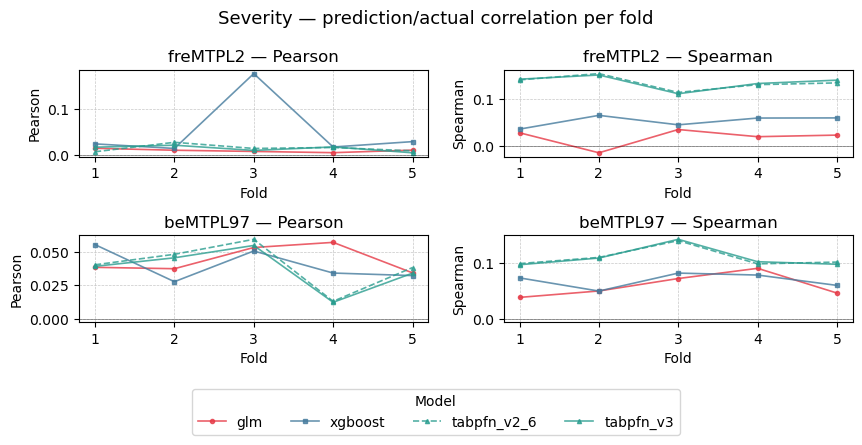

Saved to res/per_fold_correlation_lines.pdf


In [16]:
# Per-fold severity correlations — saved to res/per_fold_correlation_lines.pdf
CORR_METRICS = [("pearson_corr", "Pearson"), ("spearman_corr", "Spearman")]
datasets = ["freMTPL2", "beMTPL97"]

fig_width_in  = 7.2 * 1.2
fig_height_in = 3.4 * 1.2

fig, axes = plt.subplots(
    len(datasets), len(CORR_METRICS),
    figsize=(fig_width_in, fig_height_in),
    squeeze=False,
    constrained_layout=True,
)

handles_labels = {}
for row, dataset in enumerate(datasets):
    for col, (metric, label) in enumerate(CORR_METRICS):
        ax = axes[row][col]
        sub = folds[
            (folds["dataset"] == dataset)
            & (folds["task"] == "sev")
            & (folds["metric"] == metric)
        ]
        models_present = [m for m in MODEL_ORDER if m in sub["model_display"].values]
        for model in models_present:
            md = sub[sub["model_display"] == model].sort_values("fold")
            style = MODEL_STYLES.get(model, {"color": "grey", "marker": "o", "ls": "-"})
            line, = ax.plot(
                md["fold"] + 1, md["value"],
                color=style["color"], marker=style["marker"], ls=style["ls"],
                linewidth=1.2, markersize=3, label=model, alpha=0.8,
            )
            handles_labels[model] = line
        ax.set_title(f"{dataset} — {label}")
        ax.set_xlabel("Fold")
        ax.set_ylabel(label)
        if not sub.empty:
            ax.set_xticks(range(1, sub["fold"].nunique() + 1))
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
        ax.axhline(0, color="black", linewidth=0.5, alpha=0.5)

ordered_handles = [handles_labels[m] for m in MODEL_ORDER if m in handles_labels]
ordered_labels  = [m for m in MODEL_ORDER if m in handles_labels]
fig.legend(
    ordered_handles, ordered_labels,
    loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08),
    title="Model", frameon=True,
)
fig.suptitle("Severity — prediction/actual correlation per fold", fontsize=13)
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig("../res/per_fold_correlation_lines.pdf", bbox_inches="tight")
plt.show()
print("Saved to res/per_fold_correlation_lines.pdf")

## 9. Paper table — RMSE + deviance per task per dataset
Lower is better; **bold** denotes best per (dataset, task, metric).

In [19]:
# Combined RMSE + deviance table in the paper's LaTeX format.
# Columns: dataset blocks (freMTPL2, beMTPL97) -> [freq RMSE, freq Pois Dev, sev RMSE, sev Gam Dev].

PAPER_DATASETS = ["freMTPL2", "beMTPL97"]
# Layout: (task, metric, decimal_places). RMSE for severity is shown as integers.
PAPER_COLUMNS = [
    ("freq", "exposure_weighted_rmse_rate", 3),
    ("freq", "poisson_deviance",            3),
    ("sev",  "rmse",                        0),
    ("sev",  "gamma_deviance",              3),
]
# Display label  →  model_display key. v2.6 and v3 are shown as separate rows.
PAPER_MODELS = [
    ("GLM",                  "glm"),
    ("XGBoost",              "xgboost"),
    ("TabPFN (v2.6)",        "tabpfn_v2_6"),
    ("TabPFN (v3)",          "tabpfn_v3"),
    ("TabPFN-2000 (v2.6)",   "tabpfn_2000_v2_6"),
    ("TabPFN-2000 (v3)",     "tabpfn_2000_v3"),
    ("TabPFN-5000 (v2.6)",   "tabpfn_5000_v2_6"),
    ("TabPFN-5000 (v3)",     "tabpfn_5000_v3"),
    ("TabPFN-10000 (v2.6)",  "tabpfn_10000_v2_6"),
    ("TabPFN-10000 (v3)",    "tabpfn_10000_v3"),
    ("TabPFN-50000 (v2.6)",  "tabpfn_50000_v2_6"),
    ("TabPFN-50000 (v3)",    "tabpfn_50000_v3"),
    ("TabPFN-100000 (v2.6)", "tabpfn_100000_v2_6"),
    ("TabPFN-100000 (v3)",   "tabpfn_100000_v3"),
    ("TabPFN-full (v2.6)",   "tabpfn_full_v2_6"),
    ("TabPFN-full (v3)",     "tabpfn_full_v3"),
]


def _agg(dataset: str, model: str, task: str, metric: str):
    # Return (mean, std) for one cell, or (None, None) if no rows.
    sub = folds[
        (folds["dataset"]       == dataset)
        & (folds["model_display"] == model)
        & (folds["task"]        == task)
        & (folds["metric"]      == metric)
    ]["value"]
    if sub.empty:
        return None, None
    return float(sub.mean()), float(sub.std(ddof=1))


def _fmt_cell(mean, std, decimals, best):
    if mean is None:
        return "---"
    if decimals == 0:
        body = f"{mean:.0f} \\pm {std:.0f}"
    else:
        body = f"{mean:.{decimals}f} \\pm {std:.{decimals}f}"
    return f"$\\mathbf{{{body}}}$" if best else f"${body}$"


# Pre-compute every cell so we know which mean is the column-wise minimum.
matrix = {}  # (dataset, model, task, metric) -> (mean, std)
for dataset in PAPER_DATASETS:
    for _, model in PAPER_MODELS:
        for task, metric, _ in PAPER_COLUMNS:
            matrix[(dataset, model, task, metric)] = _agg(dataset, model, task, metric)

# Best per (dataset, task, metric): smallest mean among models with data.
best_keys = set()
for dataset in PAPER_DATASETS:
    for task, metric, _ in PAPER_COLUMNS:
        candidates = [
            (m, matrix[(dataset, m, task, metric)][0])
            for _, m in PAPER_MODELS
            if matrix[(dataset, m, task, metric)][0] is not None
        ]
        if candidates:
            best_model = min(candidates, key=lambda x: x[1])[0]
            best_keys.add((dataset, best_model, task, metric))


def _row(label: str, model: str, dataset: str) -> str:
    cells = []
    for task, metric, dec in PAPER_COLUMNS:
        mean, std = matrix[(dataset, model, task, metric)]
        cells.append(_fmt_cell(mean, std, dec, (dataset, model, task, metric) in best_keys))
    # Paper layout pairs freq cells and sev cells with double-spaced wrapping.
    return (
        f"{label}\n"
        f"  & {cells[0]} & {cells[1]}\n"
        f"  & {cells[2]} & {cells[3]} \\\\"
    )


lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Performance metrics across datasets and tasks (mean $\pm$ std over 5 folds).",
    r"Frequency: exposure-weighted RMSE and Poisson deviance.",
    r"Severity: unweighted RMSE and Gamma deviance.",
    r"Lower is better; \textbf{bold} denotes best per metric per task.}",
    r"\label{tab:results}",
    r"\begin{tabular}{lcccc}",
    r"\toprule",
    r"& \multicolumn{2}{c}{Frequency} & \multicolumn{2}{c}{Severity} \\",
    r"\cmidrule(lr){2-3} \cmidrule(lr){4-5}",
    r"Model & RMSE & Pois.\ Dev. & RMSE & Gam.\ Dev. \\",
]
for di, dataset in enumerate(PAPER_DATASETS):
    lines += [r"\midrule", rf"\multicolumn{{5}}{{l}}{{\textit{{{dataset}}}}} \\",
              r"\midrule"]
    for ri, (label, model) in enumerate(PAPER_MODELS):
        # Visual break before the first subsample-size row.
        if model == "tabpfn_2000_v2_6":
            lines.append(r"\addlinespace[2pt]")
        lines.append(_row(label, model, dataset))
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]

latex_table = "\n".join(lines)
print(latex_table)
Path("../res/results_table.tex").write_text(latex_table + "\n")
print("\nAlso saved to res/results_table.tex")

\begin{table}[ht]
\centering
\caption{Performance metrics across datasets and tasks (mean $\pm$ std over 5 folds).
Frequency: exposure-weighted RMSE and Poisson deviance.
Severity: unweighted RMSE and Gamma deviance.
Lower is better; \textbf{bold} denotes best per metric per task.}
\label{tab:results}
\begin{tabular}{lcccc}
\toprule
& \multicolumn{2}{c}{Frequency} & \multicolumn{2}{c}{Severity} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
Model & RMSE & Pois.\ Dev. & RMSE & Gam.\ Dev. \\
\midrule
\multicolumn{5}{l}{\textit{freMTPL2}} \\
\midrule
GLM
  & $\mathbf{0.487 \pm 0.010}$ & $\mathbf{0.296 \pm 0.001}$
  & $21707 \pm 21556$ & $1.755 \pm 0.263$ \\
XGBoost
  & $0.492 \pm 0.010$ & $0.344 \pm 0.001$
  & $\mathbf{21670 \pm 21531}$ & $\mathbf{1.598 \pm 0.141}$ \\
TabPFN (v2.6)
  & --- & ---
  & $21730 \pm 21559$ & $2.656 \pm 0.647$ \\
TabPFN (v3)
  & --- & ---
  & $21730 \pm 21559$ & $2.641 \pm 0.655$ \\
\addlinespace[2pt]
TabPFN-2000 (v2.6)
  & $0.490 \pm 0.010$ & $0.501 \pm 0.227$
  & --